In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("devdgohil/the-oxfordiiit-pet-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/devdgohil/the-oxfordiiit-pet-dataset


In [2]:
import json
import os
import time
import torch

In [3]:
img_path = "/kaggle/input/datasets/devdgohil/the-oxfordiiit-pet-dataset/images/images"
config_path = '/kaggle/working/config.json'
mask_path = "/kaggle/input/datasets/devdgohil/the-oxfordiiit-pet-dataset/annotations/annotations/trimaps"

In [4]:
print(len(os.listdir(img_path)))
print(len(os.listdir(mask_path)))

7393
14780


In [5]:
from torchvision import datasets, transforms as T
from torch.utils.data import DataLoader, Subset, random_split

def benchmark_num_workers(batch_size, img_size, num_workers_list=[0, 2, 4, 8]):

    device = "cuda" if torch.cuda.is_available() else "cpu"

    transform = T.Compose([
        T.Resize(img_size),
        T.ToTensor()
    ])

    dataset = datasets.FakeData(transform=transform)

    results = {}
    for nw in num_workers_list:
        loader = DataLoader(dataset,
                            batch_size=batch_size,
                            shuffle=True,
                            num_workers=nw,
                            pin_memory=(device == "cuda"))
        
        start = time.time()
        for i, batch in enumerate(loader):
            
            batch = batch[0].to(device, non_blocking=True)
            
            if i>50:
                break
        end = time.time()
        
        epoch_time = end - start
        results[nw] = epoch_time
        print(f"num_workers={nw} → epoch_time={epoch_time:.4f}s")

    best_nw = min(results, key=results.get)

    sorted_results = dict(sorted(results.items(),key=lambda kv: kv[1]))
    print(f"Benchmark: {sorted_results}")
    print(f"Selected: {best_nw}")

    return best_nw 

def load_config(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        config = json.load(f)

    return config

In [6]:
from dataclasses import dataclass

@dataclass
class Utils:

    CONFIG_PATH: str = "/kaggle/working/config.json"

    def __post_init__(self):

        self.CONFIG: dict = load_config(self.CONFIG_PATH)

In [7]:
import json

config = {}
def save_config(config, path):
    with open(path, 'w') as f:
        json.dump(config, f, indent=2)

save_config(config, config_path)

utils = Utils()
config = utils.CONFIG

config.setdefault('images_dir',     img_path)
config.setdefault('mask_dir',       mask_path)
config.setdefault('checkpoint_dir', '/kaggle/working/checkpoints')
config.setdefault('best_model_dir', '/kaggle/working/best_model')

config.setdefault('img_size',       224)
config.setdefault('max_samples',    None)
config.setdefault('split_size',     0.85)
config.setdefault('cache_ram',      False)

# UNet is heavier than ResNetAE at 224 — batch 8 is safe on T4
config.setdefault('batch_size',      32)
config.setdefault('max_iterations',  60)
config.setdefault('lr',              2e-4)
config.setdefault('weight_decay',    1e-5)
config.setdefault('grad_clip',       1.0)
config.setdefault('accum_steps',     4)    # effective batch = 32
config.setdefault('patience',        10)
config.setdefault('min_delta',       1e-6)
config.setdefault('resume',          None)
config.setdefault('save_every',      5)

config.setdefault('lambda_l1',          1.0)
config.setdefault('lambda_perceptual',  0.1)
config.setdefault('lambda_seg',         0.3)   # weight of aux seg loss
config.setdefault('bce_weight',         0.4)
config.setdefault('dice_weight',        0.4)
config.setdefault('kl_weight',          0.2)
config.setdefault('num_workers', 4)

save_config(config, utils.CONFIG_PATH)

In [8]:
load_config(config_path)

{'images_dir': '/kaggle/input/datasets/devdgohil/the-oxfordiiit-pet-dataset/images/images',
 'mask_dir': '/kaggle/input/datasets/devdgohil/the-oxfordiiit-pet-dataset/annotations/annotations/trimaps',
 'checkpoint_dir': '/kaggle/working/checkpoints',
 'best_model_dir': '/kaggle/working/best_model',
 'img_size': 224,
 'max_samples': None,
 'split_size': 0.85,
 'cache_ram': False,
 'batch_size': 32,
 'max_iterations': 60,
 'lr': 0.0002,
 'weight_decay': 1e-05,
 'grad_clip': 1.0,
 'accum_steps': 4,
 'patience': 10,
 'min_delta': 1e-06,
 'resume': None,
 'save_every': 5,
 'lambda_l1': 1.0,
 'lambda_perceptual': 0.1,
 'lambda_seg': 0.3,
 'bce_weight': 0.4,
 'dice_weight': 0.4,
 'kl_weight': 0.2,
 'num_workers': 4}

In [9]:
!nvidia-smi

Mon Mar  9 13:45:51 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [12]:
!python /kaggle/input/models/dibyenducontroversy/zcd/keras/default/1/train_seg_unet.py

Rank 0 initializing on GPU Tesla T4
Rank 1 initializing on GPU Tesla T4
  [model] SegUNet | params: 13.38M
  [dirs] checkpoints → /kaggle/working/checkpoints
  [dirs] best model  → /kaggle/working/best_model
  [train] 6281 samples | [val] 1109 samples
  Starting training for 60 epochs

/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:3355: UserWarning: reduction: 'mean' divides the total loss by both the batch size and the support size.'batchmean' divides only by the batch size, and aligns with the KL div math definition.'mean' will be changed to behave the same as 'batchmean' in the next major release.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:3355: UserWarning: reduction: 'mean' divides the total loss by both the batch size and the support size.'batchmean' divides only by the batch size, and aligns with the KL div math definition.'mean' will be changed to behave the same as 'batchmean' in the next major release.
  warnings.warn(
Cor

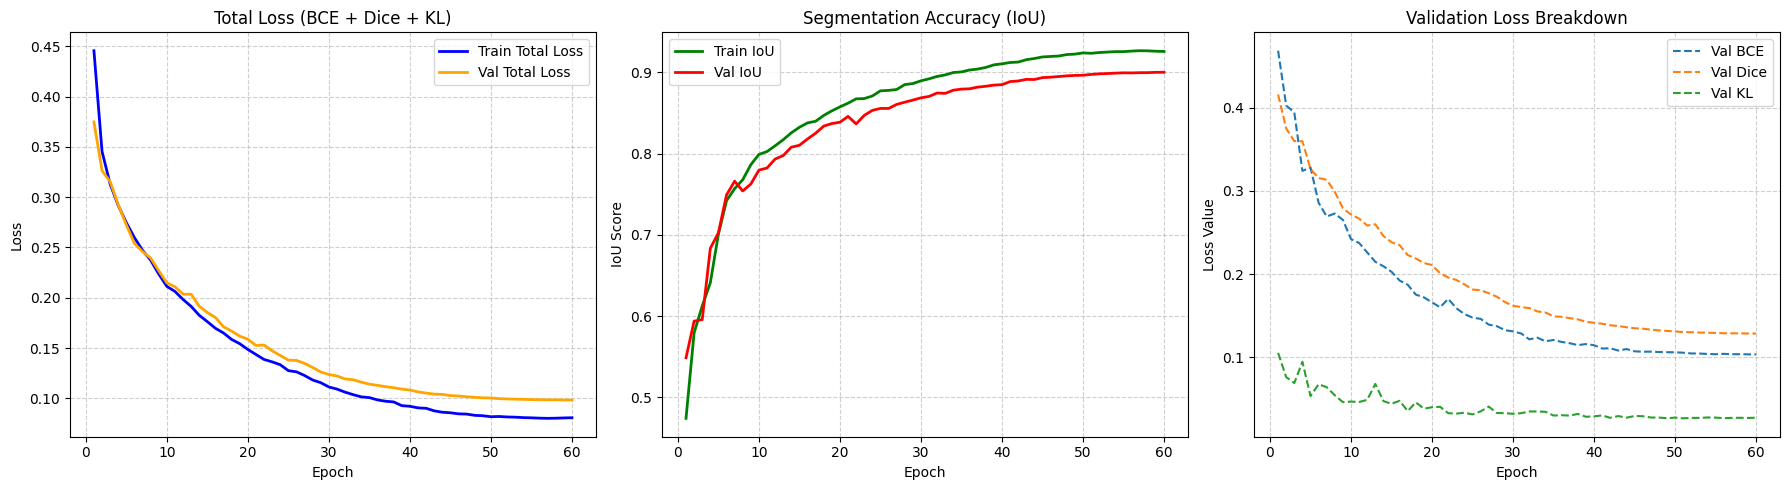

In [30]:
import os
import json
import matplotlib.pyplot as plt

def plot_training_history(history_path='/kaggle/working/checkpoints_unet/history.json'):
    if not os.path.exists(history_path):
        print(f"Error: Could not find {history_path}")
        return

    with open(history_path, 'r') as f:
        history = json.load(f)

    # Number of epochs completed
    epochs = range(1, len(history['train_total']) + 1)

    # Create a figure with 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Plot 1: Total Loss
    axes[0].plot(epochs, history['train_total'], label='Train Total Loss', color='blue', linewidth=2)
    axes[0].plot(epochs, history['val_total'], label='Val Total Loss', color='orange', linewidth=2)
    axes[0].set_title('Total Loss (BCE + Dice + KL)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True, linestyle='--', alpha=0.6)
    axes[0].legend()

    # Plot 2: Intersection over Union (IoU)
    axes[1].plot(epochs, history['train_iou'], label='Train IoU', color='green', linewidth=2)
    axes[1].plot(epochs, history['val_iou'], label='Val IoU', color='red', linewidth=2)
    axes[1].set_title('Segmentation Accuracy (IoU)')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('IoU Score')
    axes[1].grid(True, linestyle='--', alpha=0.6)
    axes[1].legend()

    # Plot 3: Validation Loss Breakdown (BCE vs Dice vs KL)
    axes[2].plot(epochs, history['breakdown']['bce']['val'], label='Val BCE', linestyle='--')
    axes[2].plot(epochs, history['breakdown']['dice']['val'], label='Val Dice', linestyle='--')
    axes[2].plot(epochs, history['breakdown']['kl']['val'], label='Val KL', linestyle='--')
    axes[2].set_title('Validation Loss Breakdown')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Loss Value')
    axes[2].grid(True, linestyle='--', alpha=0.6)
    axes[2].legend()

    plt.tight_layout()
    plt.savefig('loss_plots.png')
    plt.show()

# Run the plot
plot_training_history('/kaggle/working/checkpoints/history.json') # Update path if needed

In [31]:
import sys
sys.path.append("/kaggle/input/models/dibyenducontroversy/zcd/keras/default/1")
import train_seg_unet

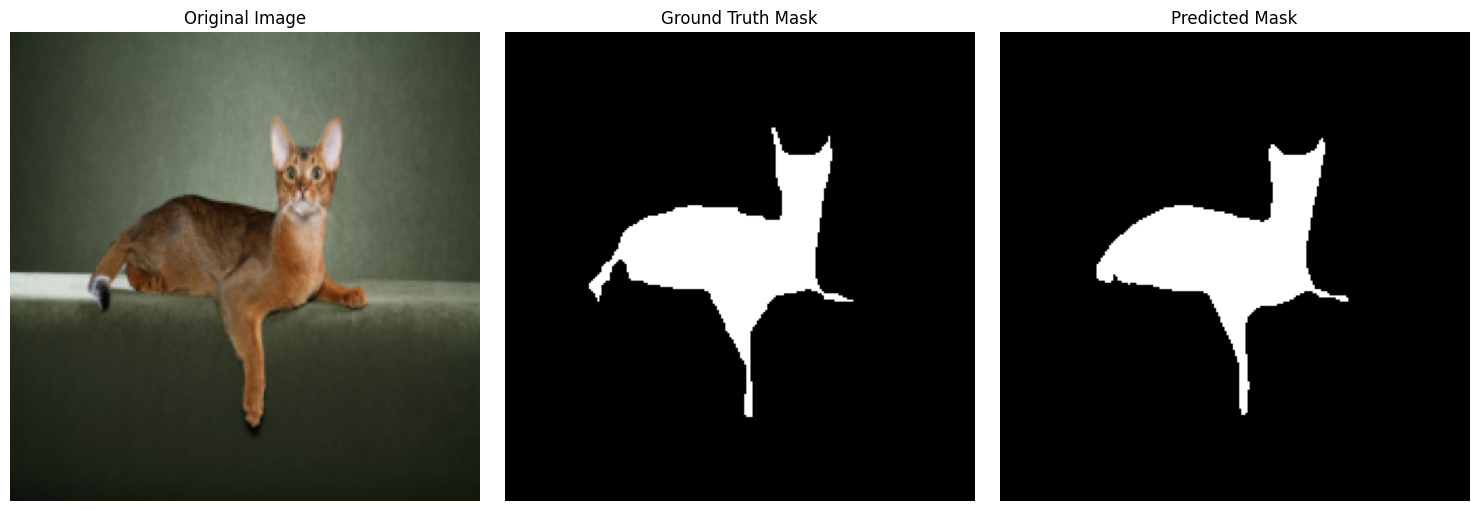

In [34]:
import torch
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import torchvision.io as io  # <-- Added missing import
from PIL import Image
import matplotlib.pyplot as plt



def predict_and_visualize(image_path, mask_path, weights_path, img_size=224, threshold=0.5):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # 1. Initialize Model and Load Weights
    model = train_seg_unet.SegUNet().to(device)
    model.load_state_dict(torch.load(weights_path, map_location=device))
    model.eval()

    # 2. Load and Preprocess the Image
    img = Image.open(image_path).convert('RGB')
    
    tf_resize = T.Resize([img_size, img_size])
    img_resized = tf_resize(img)
    img_tensor = TF.to_tensor(img_resized) 

    # Normalize for the model
    tf_norm = T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    input_tensor = tf_norm(img_tensor).unsqueeze(0).to(device)

    # 3. Load and Preprocess the Ground Truth Mask
    mask = io.read_image(mask_path)
    # Binarize: 1=Foreground, others=Background/Border
    mask_gt = (mask[0:1] == 1).float() 
    # Resize GT to match prediction size for a fair visual comparison
    mask_gt_resized = TF.resize(mask_gt, [img_size, img_size], interpolation=TF.InterpolationMode.NEAREST)
    mask_gt_plot = mask_gt_resized.squeeze().cpu().numpy()

    # 4. Run Inference
    with torch.inference_mode():
        logit = model(input_tensor)           
        mask_prob = torch.sigmoid(logit)      
        mask_binary = (mask_prob > threshold).float()
        
    mask_pred_plot = mask_binary.squeeze().cpu().numpy()

    # 5. Plot Original Image vs Ground Truth vs Predicted Mask
    plt.figure(figsize=(15, 5))
    
    # Plot 1: Original Image
    plt.subplot(1, 3, 1)
    plt.imshow(img_tensor.permute(1, 2, 0).numpy()) 
    plt.title("Original Image")
    plt.axis('off')

    # Plot 2: Ground Truth
    plt.subplot(1, 3, 2)
    plt.imshow(mask_gt_plot, cmap='gray')
    plt.title("Ground Truth Mask")
    plt.axis('off')

    # Plot 3: Prediction
    plt.subplot(1, 3, 3)
    plt.imshow(mask_pred_plot, cmap='gray')
    plt.title("Predicted Mask")
    plt.axis('off')

    plt.tight_layout()
    plt.savefig('predict_comparison.png')
    plt.show()

# --- Execution ---
mask_path = "/kaggle/input/datasets/devdgohil/the-oxfordiiit-pet-dataset/annotations/annotations/trimaps/Abyssinian_1.png"
test_image = '/kaggle/input/datasets/devdgohil/the-oxfordiiit-pet-dataset/images/images/Abyssinian_1.jpg'
weights_file = '/kaggle/working/best_model/best_weights.pth'

# Fixed function call to pass all required arguments without trailing commas
predict_and_visualize(test_image, mask_path, weights_file)

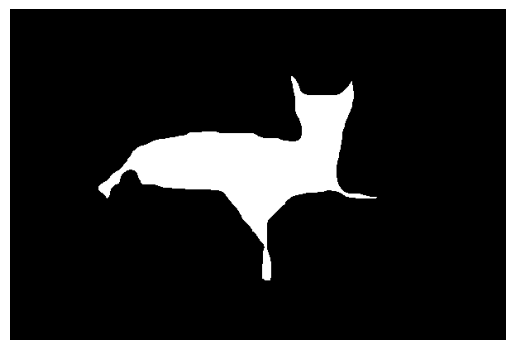

In [24]:
import torch
import torchvision.io as io
import matplotlib.pyplot as plt




In [25]:
import os
import shutil

src_dir = '/kaggle/working/checkpoints'
# We will create a zip file named 'model_checkpoints.zip' in the working directory
zip_dest = '/kaggle/working/model_checkpoints' 

if os.path.exists(src_dir):
    print(f"Zipping contents of {src_dir}...\n")
    
    # shutil.make_archive creates a zip file. 
    # It automatically appends '.zip' to the destination name provided.
    shutil.make_archive(zip_dest, 'zip', src_dir)
    
    print(f"🎉 Successfully created {zip_dest}.zip!")
else:
    print(f"❌ Could not find {src_dir}. Are you sure it hasn't been moved already?")

# Verify the zip file was created
print("\nFinal contents of /kaggle/working/:")
for item in sorted(os.listdir('/kaggle/working/')):
    if item.endswith('.zip'):
        print(f" 📦 {item} (Ready for download!)")

Zipping contents of /kaggle/working/checkpoints...

🎉 Successfully created /kaggle/working/model_checkpoints.zip!

Final contents of /kaggle/working/:
 📦 model_checkpoints.zip (Ready for download!)


In [26]:
import os
import shutil

src_dir = '/kaggle/working/best_model'
# We will create a zip file named 'model_checkpoints.zip' in the working directory
zip_dest = '/kaggle/working/segmentation_best_model' 

if os.path.exists(src_dir):
    print(f"Zipping contents of {src_dir}...\n")
    
    # shutil.make_archive creates a zip file. 
    # It automatically appends '.zip' to the destination name provided.
    shutil.make_archive(zip_dest, 'zip', src_dir)
    
    print(f"🎉 Successfully created {zip_dest}.zip!")
else:
    print(f"❌ Could not find {src_dir}. Are you sure it hasn't been moved already?")

# Verify the zip file was created
print("\nFinal contents of /kaggle/working/:")
for item in sorted(os.listdir('/kaggle/working/')):
    if item.endswith('.zip'):
        print(f" 📦 {item} (Ready for download!)")

Zipping contents of /kaggle/working/best_model...

🎉 Successfully created /kaggle/working/segmentation_best_model.zip!

Final contents of /kaggle/working/:
 📦 model_checkpoints.zip (Ready for download!)
 📦 segmentation_best_model.zip (Ready for download!)


In [27]:
!ls -lh /kaggle/working/model_checkpoints.zip

-rw-r--r-- 1 root root 2.0G Mar  9 15:05 /kaggle/working/model_checkpoints.zip


In [28]:
!ls -lh /kaggle/working/segmentation_best_model.zip

-rw-r--r-- 1 root root 140M Mar  9 15:06 /kaggle/working/segmentation_best_model.zip
